# 🧠 Playground · Red neuronal (Keras)
---

⚠️ Este notebook es **autónomo**: **no** importa nada de `src/`. Todo el código vive aquí, igual que en los notebooks de `recursos/`. La idea es **aprender practicando aquí**, replicando el estilo de la clase de Deep Learning.

### Objetivo
Entrenar una **red neuronal** (Perceptrón Multicapa, *MLP*) con **Keras / TensorFlow** para predecir la cancelación de reservas hoteleras (`is_canceled`) y compararla, de forma intuitiva, con el modelo de árboles (XGBoost) que vimos en el otro playground.

### Temas a tratar
1. Carga, limpieza, codificación y escalado de los datos
2. Definición de la red neuronal (capas, activaciones, *dropout*)
3. Entrenamiento con *early stopping*
4. Curvas de aprendizaje (*loss* y *accuracy*)
5. Evaluación (métricas, matriz de confusión, curva ROC)
6. Conclusión y comparación con XGBoost

### Información útil
+ [Documentación oficial TensorFlow — Keras](https://www.tensorflow.org/guide/keras)
+ [Machine Learning Mastery — Activation Functions](https://machinelearningmastery.com/choose-an-activation-function-for-deep-learning/)
+ [Documentación oficial Plotly](https://plotly.com/python/)

## 0. Configuración del Notebook
Importamos todas las librerías de una sola vez para tenerlas controladas. Silenciamos los avisos verbosos de TensorFlow para que la salida sea legible.

### Importación de librerías

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

# Silenciamos los logs verbosos de TensorFlow ANTES de importarlo
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

### Definición de constantes

In [2]:
# Datasets YA procesados por el notebook 02 (train/test separados, fit-on-train)
PATH_DIRECTORIO_DATOS = "../../data/processed"
PATH_TRAIN = f"{PATH_DIRECTORIO_DATOS}/train.csv"
PATH_TEST = f"{PATH_DIRECTORIO_DATOS}/test.csv"

# Columna objetivo y nombres legibles de las clases
target_column = 'is_canceled'
list_nombres_clases = ['No cancelada', 'Cancelada']

# Fijamos la semilla para que el experimento sea reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 1. Carga del dataset procesado y escalado

Igual que en el `03`, partimos del dataset que preparó [`02_preparacion_datos.ipynb`](02_preparacion_datos.ipynb): ya viene **limpio, con cardinalidad reducida, codificado *one-hot* y separado en `train`/`test`** (el preprocesado se ajustó **solo con `train`**). Aquí solo añadimos el paso **imprescindible para una red neuronal: el escalado**.

Las redes aprenden mucho mejor (y más rápido) cuando todas las variables están en una escala parecida. Sin escalar, una columna como `lead_time` (0–700+) o `adr` (0–500+) **domina** numéricamente sobre las columnas *one-hot* (0/1), y el descenso de gradiente se atasca. *(De hecho, sin un escalado correcto esta misma red se "moría" y predecía siempre la clase mayoritaria.)*

In [3]:
train_df = pd.read_csv(PATH_TRAIN)
test_df = pd.read_csv(PATH_TEST)

# Features ya codificadas (one-hot) -> float32 (el tipo nativo de TensorFlow)
X_train = train_df.drop(columns=[target_column]).astype("float32")
y_train = train_df[target_column].values
X_test = test_df.drop(columns=[target_column]).astype("float32")
y_test = test_df[target_column].values

# Garantía de seguridad: train y test deben compartir EXACTAMENTE las mismas columnas
assert list(X_train.columns) == list(X_test.columns), "Las columnas de train y test no coinciden"

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Distribución de la clase (train):', np.bincount(y_train) / len(y_train))

X_train: (94850, 155) | X_test: (23713, 155)
Distribución de la clase (train): [0.6274117 0.3725883]


### Escalado (ajustado **solo en `train`**)

Ajustamos el `StandardScaler` con `X_train` (`.fit_transform`) y aplicamos **esa misma** transformación a `X_test` (`.transform`). Es exactamente el patrón *fit-on-train* del que hablamos: el escalador **aprende** la media y la desviación típica de cada columna, y esos parámetros salen **solo del entrenamiento**. En producción se haría igual (`scaler.transform(reserva_nueva)`), guardando el escalador junto al modelo.

> El dataset ya está limpio y con cardinalidad acotada (~150 columnas densas), así que usamos el `StandardScaler` por defecto (`with_mean=True`): centrar y escalar todas las columnas va bien para una red densa.

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # aprende media/desv. SOLO del train
X_test_s = scaler.transform(X_test)         # aplica la MISMA transformación al test

print('X_train_s:', X_train_s.shape)
print('X_test_s :', X_test_s.shape)
print('y_train  :', y_train.shape, '| y_test:', y_test.shape)

X_train_s: (94850, 155)
X_test_s : (23713, 155)
y_train  : (94850,) | y_test: (23713,)


## 2. Definición de la red neuronal
Construimos un **Perceptrón Multicapa (MLP)** sencillo con la API `Sequential` de Keras, dando un **nombre** a cada capa (`i1`, `h1`, ...) igual que en clase:

- **`i1`** — capa de entrada con tantas neuronas como columnas tras el one-hot.
- **`h1` (64)**, **`h2` (32)**, **`h3` (16)** — capas ocultas con activación **ReLU** (embudo: cada capa más pequeña).
- **`d1`** — `Dropout(0.3)`: apaga el 30 % de las neuronas en cada paso de entrenamiento para **reducir el sobreajuste**.
- **`o1`** — capa de salida con **1 neurona** y activación **sigmoid** (devuelve una probabilidad entre 0 y 1), porque es **clasificación binaria**.

Compilamos con el optimizador **Adam** (`lr = 1e-3`) y la pérdida **`binary_crossentropy`**, la estándar para clasificación binaria.

In [5]:
modelo = models.Sequential([
    layers.Input(shape=(X_train_s.shape[1],), name='i1'),
    layers.Dense(64, activation='relu', name='h1'),
    layers.Dropout(0.3, name='d1'),
    layers.Dense(32, activation='relu', name='h2'),
    layers.Dense(16, activation='relu', name='h3'),
    layers.Dense(1, activation='sigmoid', name='o1'),
])

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 64)             │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d1 (Dropout)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h3 (Dense)                      │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,609 (49.25 KB)

 Trainable params: 12,609 (49.25 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento
Entrenamos hasta un máximo de **60 épocas** con lotes (*batch*) de 512 muestras, reservando un 20 % del train como **validación**.

Mantenemos **`EarlyStopping`** —para cuando la `val_loss` deja de mejorar y restaura los **mejores pesos**— pero subimos la **paciencia a 10**. Con `patience=5` paraba muy pronto (~12 épocas), nada más aplanarse la curva; con `patience=10` le damos margen para entrenar más y poder **ver la curva completa**: la bajada inicial, la meseta y el punto en que la `val_loss` deja de mejorar (incluso repunta) mientras la de entrenamiento sigue cayendo —ese hueco es el **sobreajuste**. Gracias a `restore_best_weights=True`, el modelo que evaluamos sigue siendo el de la **mejor** época, no el de la última.

In [6]:
# patience alto (10): toleramos más épocas "planas" antes de parar, así vemos
# la curva completa (la meseta e incluso el inicio del sobreajuste). Aun así,
# restore_best_weights=True nos devuelve los pesos de la MEJOR época.
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = modelo.fit(
    X_train_s, y_train,
    epochs=60,
    batch_size=512,
    validation_split=0.2,
    verbose=1,
    callbacks=[es],
)

Epoch 1/60


  1/149 ━━━━━━━━━━━━━━━━━━━━ 1:33 631ms/step - accuracy: 0.4277 - loss: 0.7213

 21/149 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5566 - loss: 0.6800    

 35/149 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5913 - loss: 0.6633

 37/149 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5951 - loss: 0.6612

...

 40/149 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8721 - loss: 0.2841 

 74/149 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8717 - loss: 0.2844

112/149 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8716 - loss: 0.2841

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8715 - loss: 0.2837 - val_accuracy: 0.8625 - val_loss: 0.3000


Restoring model weights from the end of the best epoch: 58.


## 4. Curvas de aprendizaje
Visualizamos la evolución de la **pérdida** y la **accuracy** en entrenamiento vs. validación. Si las curvas de train y validación se separan mucho, hay **sobreajuste**; si van juntas y se estabilizan, el entrenamiento es sano.

In [7]:
hist = history.history
epochs = list(range(1, len(hist['loss']) + 1))

fig = make_subplots(rows=1, cols=2, subplot_titles=('Loss', 'Accuracy'))

# --- Loss ---
fig.add_trace(go.Scatter(x=epochs, y=hist['loss'], mode='lines+markers', name='loss (train)'), row=1, col=1)
fig.add_trace(go.Scatter(x=epochs, y=hist['val_loss'], mode='lines+markers', name='val_loss'), row=1, col=1)

# --- Accuracy ---
fig.add_trace(go.Scatter(x=epochs, y=hist['accuracy'], mode='lines+markers', name='accuracy (train)'), row=1, col=2)
fig.add_trace(go.Scatter(x=epochs, y=hist['val_accuracy'], mode='lines+markers', name='val_accuracy'), row=1, col=2)

fig.update_xaxes(title_text='Época', row=1, col=1)
fig.update_xaxes(title_text='Época', row=1, col=2)
fig.update_yaxes(title_text='Loss', row=1, col=1)
fig.update_yaxes(title_text='Accuracy', row=1, col=2)
fig.update_layout(title_text='Curvas de aprendizaje de la red neuronal', width=950, height=450)
fig.show(renderer='notebook_connected')

## 5. Evaluación
La red devuelve **probabilidades** (gracias a la sigmoid). Aplicamos el umbral de **0.5** para obtener la clase predicha y calculamos las métricas habituales. Como el problema está desbalanceado, miramos también **precision**, **recall**, **F1** y **ROC-AUC**, no solo el *accuracy*.

In [8]:
proba = modelo.predict(X_test_s).ravel()
pred = (proba >= 0.5).astype(int)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred)
rec = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)
auc = roc_auc_score(y_test, proba)

print(f"Accuracy:  {acc:.4f}")
print(f"Precisión: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

  1/742 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step

 67/742 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step

147/742 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step

228/742 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step

275/742 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step

...

699/742 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step

736/742 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step

742/742 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

742/742 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


Accuracy:  0.8640
Precisión: 0.8336
Recall:    0.7935
F1-Score:  0.8131
ROC-AUC:   0.9390


### Matriz de confusión

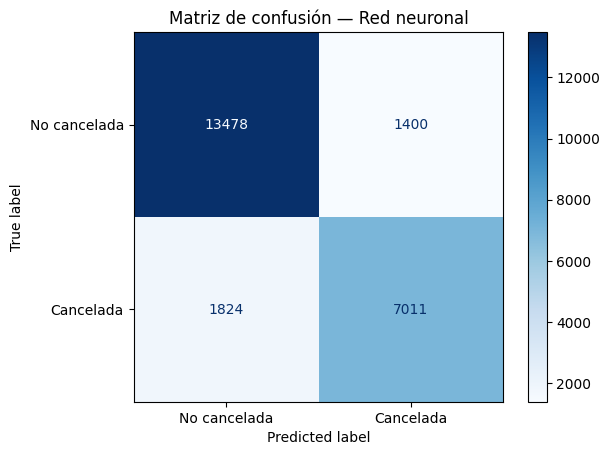

In [9]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list_nombres_clases)
disp.plot(cmap='Blues')
plt.title('Matriz de confusión — Red neuronal')
plt.show()

### Curva ROC
La curva ROC enfrenta la tasa de verdaderos positivos (TPR) frente a la de falsos positivos (FPR) según el umbral; el AUC resume su calidad (0.5 = azar, 1 = perfecto).

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, proba)

fig = px.area(
    x=fpr, y=tpr,
    title=f'Curva ROC (AUC = {auc:.4f})',
    labels=dict(x='Tasa de Falsos Positivos (FPR)', y='Tasa de Verdaderos Positivos (TPR)'),
    width=700, height=500,
)
fig.add_shape(type='line', line=dict(dash='dash'), x0=0, x1=1, y0=0, y1=1)
fig.update_yaxes(scaleanchor='x', scaleratio=1)
fig.update_xaxes(constrain='domain')
fig.show(renderer='notebook_connected')

## 6. Conclusión
- Con los datos **bien preparados y escalados** (fit-on-train), la **red neuronal (MLP)** entrena de forma sana (la *loss* baja de ~0.68 a ~0.29 y se estabiliza) y alcanza un **ROC-AUC ≈ 0.94**, un resultado muy competitivo.
- Aun así, se queda **un pelín por detrás del XGBoost** del notebook `03` (ROC-AUC ≈ 0.95): en **datos tabulares** los modelos de *gradient boosting* suelen ir por delante y, sobre todo, son **más sencillos de ajustar y entrenar** (no necesitan escalado, ni elegir arquitectura, ni tantas épocas).
- Lección práctica de este cuaderno: **el escalado importa de verdad en redes neuronales**. Sin un escalado adecuado, la red se "moría" y predecía siempre la clase mayoritaria (ROC-AUC 0.5). Centrar y escalar las columnas —ajustando el escalador **solo con el train**— es lo que la hace converger.
- Las redes neuronales brillan más con **datos no estructurados** (imágenes, texto, audio); para tablas como esta, el *boosting* sigue siendo la opción de referencia. Aun así, ha sido un gran ejercicio para **aprender practicando** cómo se construye, entrena y evalúa una red con Keras. 🧠